# Getting optimal networks from Kayson's YANAT library 

In [63]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [64]:
import sys
import os
sys.path.append(os.path.abspath('..'))

from pathlib import Path

from yanat import generative_game_theoric_numba as gen
from yanat import utils as ut
from vizman import viz
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import netneurotools.datasets as nntd
from scipy.spatial.distance import pdist, squareform

In [65]:
viz.set_visual_style()

In [66]:
# Path to distance_matrix
data_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/optimized_networks_diffusion")
DISTANCE_MATRIX_PATH = data_path / "02_distance_matrices/distance_matrix_100.npy"

# Distance matrix 
distance_matrix = np.load(DISTANCE_MATRIX_PATH)

# Output directory for generated connectomes
OUTPUT_DIR = data_path / "01_connectomes"
OUTPUT_DIR.mkdir(exist_ok=True)


In [67]:
# Consensus 
conn_matrix = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/hcp_schaefer_100_dataset/01_connectomes/01_consensus_bin_density_10_percent_100.npy") # /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/hcp_schaefer_100_dataset/01_connectomes/00_connectomes_density10.npy") # nntd.fetch_famous_gmat("human_struct_scale033")["conn"]
connectivity = ut.minmax_normalize(conn_matrix)
conn_matrix.shape
# coordinates = human_struct["coords"]

(1, 100, 100)

In [68]:
resource = connectivity.sum(0)/(connectivity.sum(0).max()) 

In [69]:
n_iterations = 10000 # this needs to be higher depending on the metric.
beta_vec = np.ones(n_iterations)
penalty_vec = np.zeros(n_iterations)
batch_size_vec = np.full(n_iterations, 10)
payoff_tolerance_vec = 10 * (1 - np.exp(-2 * np.linspace(0, 1, n_iterations)))
payoff_tolerance_mat = np.zeros((n_iterations, connectivity.shape[0]))
for i in range(connectivity.shape[0]):
    payoff_tolerance_mat[:, i] = ((connectivity.astype(bool)[i].sum())*2) * (1 - np.exp(-2 * np.linspace(0, 1, n_iterations)))
weight = 0.1
resource_scaling = 10

Simulating network evolution: 100%|██████████| 9999/9999 [00:07<00:00, 1414.82it/s]


Initial range: alpha=[0.05, 200], density=[0.0, 1.0]
Target density: 0.1
Iteration 1: Testing alpha=20.045


Simulating network evolution: 100%|██████████| 9999/9999 [00:07<00:00, 1377.71it/s]


Alpha=20.045 → density=0.3244444444444444, diff from target=0.22444444444444442
Iteration 2: Testing alpha=6.212842465753425


Simulating network evolution: 100%|██████████| 9999/9999 [00:07<00:00, 1286.22it/s]


Alpha=6.212842465753425 → density=0.1509090909090909, diff from target=0.050909090909090904
Iteration 3: Testing alpha=4.13381127248721


Simulating network evolution: 100%|██████████| 9999/9999 [00:07<00:00, 1324.35it/s]


Alpha=4.13381127248721 → density=0.11353535353535353, diff from target=0.013535353535353525
Iteration 4: Testing alpha=3.64695120975297


Simulating network evolution: 100%|██████████| 9999/9999 [00:08<00:00, 1174.93it/s]

Alpha=3.64695120975297 → density=0.10222222222222223, diff from target=0.0022222222222222227


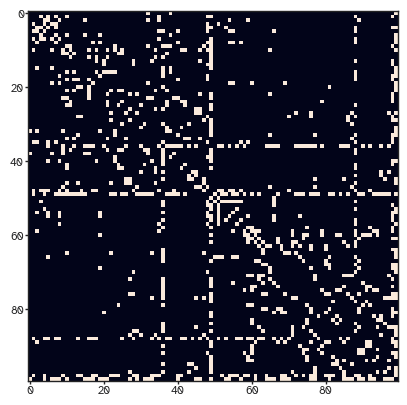

In [ ]:
result_prop=gen.find_optimal_alpha(
    distance_matrix=distance_matrix,
    empirical_connectivity=connectivity[0,:,:],
    distance_fn="propagation", # gen.propagation_distance,
    n_iterations=n_iterations, 
    alpha_range=(0.05, 200), 
    max_search_iterations=10,
    seed=2,
    batch_size=batch_size_vec,
)


plt.imshow(result_prop["evolution"][:,:,-1])

In [101]:
prop_output = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_propagation/01_connectomes") # /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/optimized_networks_propagation")
prop_output.mkdir(exist_ok=True)


np.save(prop_output / "propagation_10_percent.npy", np.array([result_prop["evolution"][:,:,-1]]))

Simulating network evolution: 100%|██████████| 9999/9999 [00:28<00:00, 345.19it/s]


Initial range: alpha=[0.05, 200], density=[0.0, 0.20727272727272728]
Target density: 0.1
Iteration 1: Testing alpha=96.5171052631579


Simulating network evolution: 100%|██████████| 9999/9999 [00:27<00:00, 364.05it/s]


Alpha=96.5171052631579 → density=0.15333333333333332, diff from target=0.053333333333333316
Iteration 2: Testing alpha=62.96332951945082


Simulating network evolution: 100%|██████████| 9999/9999 [00:27<00:00, 361.25it/s]


...

Alpha=48.10879338291382 → density=0.12, diff from target=0.01999999999999999
Iteration 4: Testing alpha=40.09899448576152


Simulating network evolution: 100%|██████████| 9999/9999 [00:27<00:00, 364.73it/s]


Alpha=40.09899448576152 → density=0.11212121212121212, diff from target=0.012121212121212116
Iteration 5: Testing alpha=35.7693734602738


Simulating network evolution: 100%|██████████| 9999/9999 [00:31<00:00, 318.60it/s]

Alpha=35.7693734602738 → density=0.10424242424242425, diff from target=0.004242424242424242


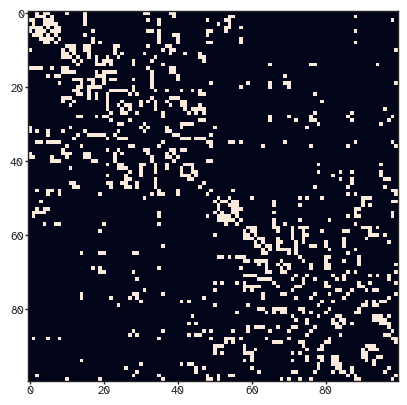

In [97]:
result_res=gen.find_optimal_alpha(
    distance_matrix=distance_matrix,
    empirical_connectivity=connectivity[0,:,:],
    distance_fn="resistance", 
    n_iterations=n_iterations, 
    alpha_range=(0.05, 200), 
    max_search_iterations=10,
    seed=2,
    batch_size=batch_size_vec,
)

plt.imshow(result_res["evolution"][:,:,-1])

In [103]:
res_output = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_resistance/01_connectomes") # /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/optimized_networks_propagation")
res_output.mkdir(exist_ok=True, parents=True)


np.save(res_output / "resistance_10_percent.npy", np.array([result_res["evolution"][:,:,-1]]))

Simulating network evolution: 100%|██████████| 9999/9999 [00:10<00:00, 940.25it/s]


Initial range: alpha=[0.05, 200], density=[0.0, 0.4131313131313131]
Target density: 0.1
Iteration 1: Testing alpha=48.44865525672372


Simulating network evolution: 100%|██████████| 9999/9999 [00:10<00:00, 939.42it/s]


Alpha=48.44865525672372 → density=0.08161616161616161, diff from target=-0.01838383838383839
Iteration 2: Testing alpha=56.85278223517475


Simulating network evolution: 100%|██████████| 9999/9999 [00:10<00:00, 941.33it/s]

Alpha=56.85278223517475 → density=0.09171717171717171, diff from target=-0.008282828282828295


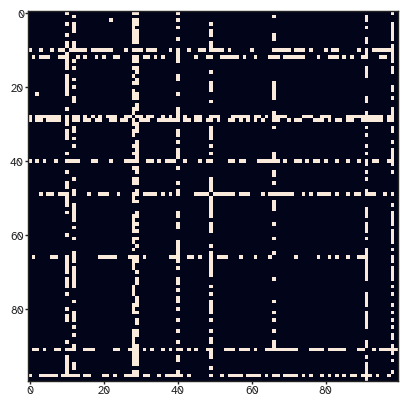

In [98]:
result_topo=gen.find_optimal_alpha(
    distance_matrix=distance_matrix,
    empirical_connectivity=connectivity[0,:,:],
    distance_fn="topological", 
    n_iterations=n_iterations, 
    alpha_range=(0.05, 200), 
    max_search_iterations=10,
    seed=2,
    batch_size=batch_size_vec,
)

plt.imshow(result_topo["evolution"][:,:,-1])

In [104]:
topo_output = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_topology/01_connectomes") # /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/optimized_networks_propagation")
topo_output.mkdir(exist_ok=True, parents=True)


np.save(topo_output / "topology_10_percent.npy", np.array([result_topo["evolution"][:,:,-1]]))

Simulating network evolution: 100%|██████████| 9999/9999 [00:09<00:00, 1024.07it/s]


Initial range: alpha=[0.05, 200], density=[0.02, 1.0]
Target density: 0.1
Iteration 1: Testing alpha=16.372448979591837


Simulating network evolution: 100%|██████████| 9999/9999 [00:12<00:00, 831.38it/s]


Alpha=16.372448979591837 → density=0.1195959595959596, diff from target=0.019595959595959597
Iteration 2: Testing alpha=13.160932648921637


Simulating network evolution: 100%|██████████| 9999/9999 [00:12<00:00, 792.14it/s]

Alpha=13.160932648921637 → density=0.0993939393939394, diff from target=-0.00060606060606061


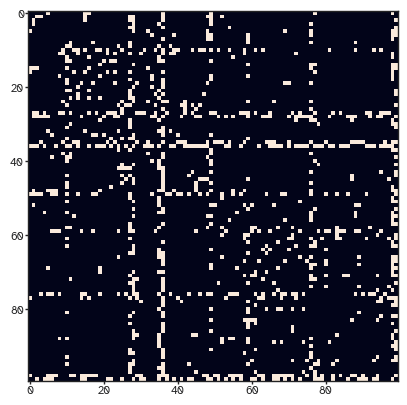

In [ ]:
result_sp=gen.find_optimal_alpha(
    distance_matrix=distance_matrix,
    empirical_connectivity=connectivity[0,:,:],
    distance_fn="shortest", 
    n_iterations=n_iterations, 
    alpha_range=(0.05, 200), 
    max_search_iterations=10,
    seed=2,
    batch_size=batch_size_vec,
)

plt.imshow(result_sp["evolution"][:,:,-1])

In [105]:
routing_output = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_routing/01_connectomes") # /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/optimized_networks_propagation")
routing_output.mkdir(exist_ok=True, parents=True)

np.save(routing_output / "routing_10_percent.npy", np.array([result_sp["evolution"][:,:,-1]]))

Simulating network evolution: 100%|██████████| 9999/9999 [00:18<00:00, 532.06it/s]


Initial range: alpha=[0.05, 200], density=[0.0, 0.12484848484848485]
Target density: 0.1
Iteration 1: Testing alpha=160.20412621359225


Simulating network evolution: 100%|██████████| 9999/9999 [00:18<00:00, 530.87it/s]


Alpha=160.20412621359225 → density=0.12424242424242424, diff from target=0.024242424242424232
Iteration 2: Testing alpha=128.95454061094011


Simulating network evolution: 100%|██████████| 9999/9999 [00:18<00:00, 536.78it/s]


...

Alpha=90.94422735386804 → density=0.11737373737373738, diff from target=0.017373737373737375
Iteration 5: Testing alpha=77.49000437205625


Simulating network evolution: 100%|██████████| 9999/9999 [00:18<00:00, 543.96it/s]


Alpha=77.49000437205625 → density=0.11212121212121212, diff from target=0.012121212121212116
Iteration 6: Testing alpha=69.11811200750962


Simulating network evolution: 100%|██████████| 9999/9999 [00:19<00:00, 521.23it/s]

Alpha=69.11811200750962 → density=0.10848484848484849, diff from target=0.008484848484848484


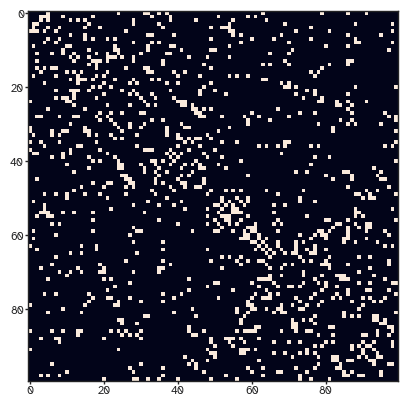

In [95]:
result_heat=gen.find_optimal_alpha(
    distance_matrix=distance_matrix,
    empirical_connectivity=connectivity[0,:,:],
    distance_fn="heat", 
    n_iterations=n_iterations, 
    alpha_range=(0.05, 200), 
    max_search_iterations=10,
    seed=2,
    batch_size=batch_size_vec,
)

plt.imshow(result_heat["evolution"][:,:,-1])

In [110]:
heat_output = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_heat/01_connectomes") # /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/optimized_networks_propagation")
heat_output.mkdir(exist_ok=True, parents=True)
np.save(heat_output / "heat_10_percent.npy", np.array([result_sp["evolution"][:,:,-1]]))

# ATTENTION! THIS IS POTENTIALLY BULLSHIT!! 
diffusion_output = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_diffusion/01_connectomes") # /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/optimized_networks_propagation")
diffusion_output.mkdir(exist_ok=True, parents=True)
np.save(diffusion_output / "diffusion_10_percent.npy", np.array([result_heat["evolution"][:,:,-1]]))

In [72]:
from yanat import core

In [73]:
core.communicability(result["evolution"][:,:,-1]).mean() # connectivity[0,:,:]).mean() # , distance_matrix) # , weight=weight, resource_scaling=resource_scaling)

np.float64(11918.311791529057)

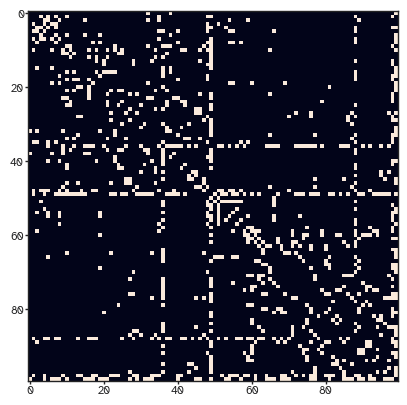

In [74]:
plt.imshow(result["evolution"][:,:,-1])

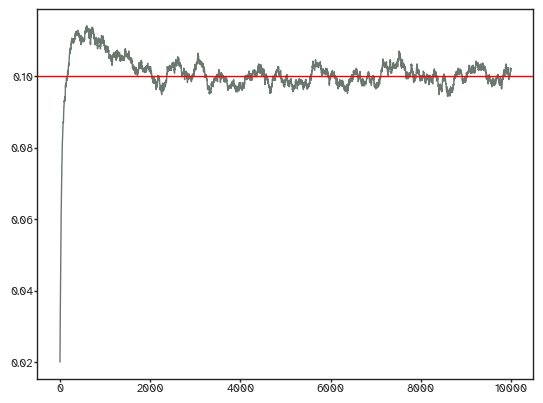

In [75]:
plt.plot(np.mean(result["evolution"], axis=(0,1)))
plt.axhline(0.1, color="red")


In [ ]:
# result_diff = gen.find_optimal_alpha(
#     distance_matrix=distance_matrix,
#     empirical_connectivity=connectivity[0, :, :],
#     distance_fn=gen.diffusion_distance,
#     n_iterations=n_iterations,
#     alpha_range=(0.05, 200),
#     max_search_iterations=10,
#     seed=2,
#     batch_size=batch_size_vec,
# )

AttributeError: module 'yanat.generative_game_theoric_numba' has no attribute 'diffusion_distance'

### OLD: Propagation

Simulating network evolution: 100%|██████████| 9999/9999 [00:07<00:00, 1373.35it/s]


Initial range: alpha=[0.05, 200], density=[0.0, 1.0]
Target density: 0.1
Iteration 1: Testing alpha=20.045


Simulating network evolution: 100%|██████████| 9999/9999 [00:07<00:00, 1252.45it/s]


Alpha=20.045 → density=0.3244444444444444, diff from target=0.22444444444444442
Iteration 2: Testing alpha=6.212842465753425


Simulating network evolution: 100%|██████████| 9999/9999 [00:08<00:00, 1154.72it/s]


Alpha=6.212842465753425 → density=0.1509090909090909, diff from target=0.050909090909090904
Iteration 3: Testing alpha=4.13381127248721


Simulating network evolution: 100%|██████████| 9999/9999 [00:09<00:00, 1110.77it/s]


Alpha=4.13381127248721 → density=0.11353535353535353, diff from target=0.013535353535353525
Iteration 4: Testing alpha=3.64695120975297


Simulating network evolution: 100%|██████████| 9999/9999 [00:07<00:00, 1284.23it/s]


Alpha=3.64695120975297 → density=0.10222222222222223, diff from target=0.0022222222222222227


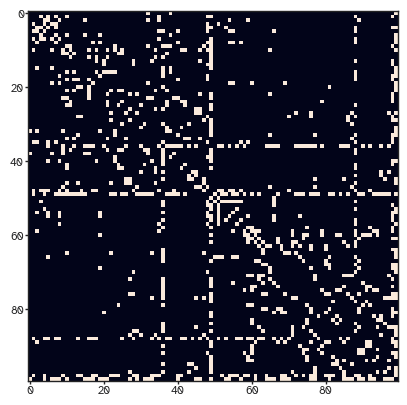

In [99]:
# Propagation output directory
prop_output = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_propagation/01_connectomes") # /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/optimized_networks_propagation")
prop_output.mkdir(exist_ok=True)

result_prop = gen.find_optimal_alpha(
    distance_matrix=distance_matrix,
    empirical_connectivity=connectivity[0, :, :],
    distance_fn=gen.propagation_distance,
    n_iterations=n_iterations,
    alpha_range=(0.05, 200),
    max_search_iterations=10,
    seed=2,
    batch_size=batch_size_vec,
)

result_prop.keys()

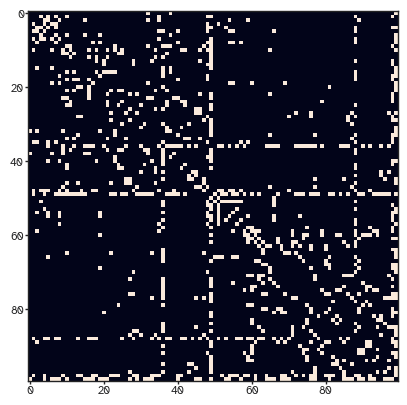

In [ ]:
plt.imshow(result_prop["evolution"][:,:,-1])

np.save(prop_output / "propagation_10_percent.npy", np.array([result_prop["evolution"][:,:,-1]]))

In [ ]:
# # Routing output directory
# route_output = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_routing/01_connectomes")
# route_output.mkdir(exist_ok=True)

# result_route = gen.find_optimal_alpha(
#     distance_matrix=distance_matrix,
#     empirical_connectivity=connectivity[0, :, :],
#     distance_fn=gen.routing_distance,
#     n_iterations=n_iterations,
#     alpha_range=(0.05, 200),
#     max_search_iterations=10,
#     seed=2,
#     batch_size=batch_size_vec,
# )

AttributeError: module 'yanat.generative_game_theoric_numba' has no attribute 'routing_distance'

In [ ]:
np.save(route_out / "routing_10_percent.npy", np.array([result_route["evolution"][:,:,-1]]))

# OLD: AI attempt

In [ ]:
"""
Generate Artificial Brain Networks using YANAT's Game-Theoretic Framework
=========================================================================
Generates 20 synthetic brain networks for each of three communication models:
  - Propagation  (propagation_distance)
  - Diffusion    (heat_kernel_distance)
  - Routing      (shortest_path_distance)
"""

import numpy as np
from pathlib import Path
from yanat.generative_game_theoric import (
    simulate_network_evolution,
    propagation_distance,
    heat_kernel_distance,
    shortest_path_distance,
    find_optimal_alpha,
)

# Configuration
N_NODES = 100
DENSITY = 0.10
N_NETWORKS = 20

In [ ]:



# ── Define communication models ───────────────────────────────────────────────
# Each entry: (label, communication_model_function)
communication_models = {
    # "propagation": propagation_distance,
    "diffusion": heat_kernel_distance,
    # "routing": shortest_path_distance,
}

# ── Generate networks ─────────────────────────────────────────────────────────
results = {}

for model_name, comm_model in communication_models.items():
    print(f"\n{'='*60}")
    print(f"  Generating {N_NETWORKS} networks with: {model_name}")
    print(f"{'='*60}")

    networks = []

    for i in range(N_NETWORKS):
        seed = i  # Reproducible but distinct per network

        # Find the optimal trade-off parameter (alpha) for this model + seed.
        # alpha balances wiring cost (distance) vs. communication value.
        alpha = find_optimal_alpha(
            distance_matrix=distance_matrix,
            communication_model=comm_model,
            density=DENSITY,
            seed=seed,
            empirical_alpha=None,  # No empirical alpha; we want the optimal for this setup.
            distance_fn=comm_model,  # Use the communication model as the distance function for payoff calculations.
        )

        # Simulate the network evolution using the game-theoretic framework.
        network = simulate_network_evolution(
            distance_matrix=distance_matrix,
            communication_model=comm_model,
            density=DENSITY,
            alpha=alpha,
            seed=seed,
        )

        networks.append(network)
        actual_density = network.sum() / (N_NODES * (N_NODES - 1))
        print(f"  [{model_name}] Network {i+1:2d}/{N_NETWORKS} | "
              f"alpha={alpha:.4f} | density={actual_density:.4f}")

    # Stack all networks: shape (N_NETWORKS, N_NODES, N_NODES)
    networks_array = np.array(networks)
    results[model_name] = networks_array

    # Save to disk
    out_path = OUTPUT_DIR / f"{model_name}_10_percent.npy"
    np.save(out_path, networks_array)
    print(f"  Saved → {out_path}")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  Summary")
print(f"{'='*60}")
for model_name, nets in results.items():
    mean_density = np.mean([
        n.sum() / (N_NODES * (N_NODES - 1)) for n in nets
    ])
    print(f"  {model_name:15s} | shape: {nets.shape} | "
          f"mean density: {mean_density:.4f}")

print(f"\nAll networks saved to: {OUTPUT_DIR.resolve()}")


  Generating 20 networks with: diffusion


TypeError: find_optimal_alpha() missing 1 required positional argument: 'empirical_connectivity'

In [ ]:
"""
Generate Artificial Brain Networks using YANAT's Game-Theoretic Framework
=========================================================================
Generates 20 synthetic brain networks for each of three communication models:
  - Propagation  (propagation_distance)
  - Diffusion    (heat_kernel_distance)
  - Routing      (shortest_path_distance)

Parameters:
  - 100 nodes (Schaefer atlas)
  - 10% target density
  - User-supplied Euclidean distance matrix

Requirements:
  pip install yanat numpy scipy
"""

import numpy as np
from pathlib import Path
from yanat.generative_game_theoric import (
    simulate_network_evolution,
    propagation_distance,
    heat_kernel_distance,
    shortest_path_distance,
    find_optimal_alpha,
)

# ── Configuration ─────────────────────────────────────────────────────────────
N_NODES = 100
TARGET_DENSITY = 0.10
N_NETWORKS = 20
N_ITERATIONS = 10_000       # simulation steps per network evolution
BATCH_SIZE = 32             # edge flips evaluated per iteration
BETA = 1.0                  # wiring cost weight
CONNECTIVITY_PENALTY = 10.0 # penalty for disconnected components
N_JOBS = -1                 # parallel cores (-1 = all)


# ── Create a dummy empirical connectivity at target density ───────────────────
# find_optimal_alpha needs an empirical_connectivity matrix to derive the
# target density.  We build a random symmetric binary matrix at 10% density.
rng_dummy = np.random.default_rng(seed=999)
n_possible_edges = N_NODES * (N_NODES - 1) // 2
n_target_edges = int(round(TARGET_DENSITY * N_NODES * (N_NODES - 1) / 2))

upper_tri_indices = np.triu_indices(N_NODES, k=1)
edge_mask = np.zeros(n_possible_edges, dtype=int)
edge_mask[:n_target_edges] = 1
rng_dummy.shuffle(edge_mask)

dummy_empirical = np.zeros((N_NODES, N_NODES), dtype=float)
dummy_empirical[upper_tri_indices] = edge_mask
dummy_empirical += dummy_empirical.T  # symmetrise

print(f"Dummy empirical density: "
      f"{dummy_empirical.sum() / (N_NODES * (N_NODES - 1)):.4f}")

# ── Define communication models ──────────────────────────────────────────────
communication_models = {
    "propagation": propagation_distance,   # propagation (LAM/SAR)
    "diffusion":   heat_kernel_distance,   # diffusion   (heat kernel)
    "routing":     shortest_path_distance, # routing     (shortest path)
}

# ── Generate networks ─────────────────────────────────────────────────────────
results = {}

for model_name, distance_fn in communication_models.items():
    print(f"\n{'=' * 65}")
    print(f"  Model: {model_name}")
    print(f"{'=' * 65}")

    # ── Step 1: Find optimal alpha for this communication model ───────────
    # Alpha balances communication efficiency vs. wiring cost so the
    # resulting network lands at the target density.
    print(f"\n  Finding optimal alpha for {model_name}...")
    alpha_result = find_optimal_alpha(
        distance_matrix=distance_matrix,
        empirical_connectivity=dummy_empirical,
        distance_fn=distance_fn,
        n_iterations=N_ITERATIONS,
        beta=BETA,
        alpha_range=(0.05, 100.0),
        tolerance=0.01,
        max_search_iterations=20,
        random_seed=42,
        batch_size=BATCH_SIZE,
        symmetric=True,
        n_jobs=N_JOBS,
        connectivity_penalty=CONNECTIVITY_PENALTY,
    )
    optimal_alpha = alpha_result["alpha"]
    print(f"  ✓ Optimal alpha = {optimal_alpha:.4f}  "
          f"(achieved density = {alpha_result['density']:.4f})")

    # ── Step 2: Generate N_NETWORKS networks with this alpha ──────────────
    networks = []
    for i in range(N_NETWORKS):
        seed = i  # distinct seed per network

        print(f"  Generating network {i + 1:2d}/{N_NETWORKS} "
              f"(seed={seed}) ...", end=" ", flush=True)

        history = simulate_network_evolution(
            distance_matrix=distance_matrix,
            n_iterations=N_ITERATIONS,
            distance_fn=distance_fn,
            alpha=optimal_alpha,
            beta=BETA,
            connectivity_penalty=CONNECTIVITY_PENALTY,
            n_jobs=N_JOBS,
            batch_size=BATCH_SIZE,
            random_seed=seed,
            symmetric=True,
        )

        # Extract the final adjacency matrix (last time-step)
        final_network = history[:, :, -1]
        networks.append(final_network)

        actual_density = final_network.sum() / (N_NODES * (N_NODES - 1))
        print(f"density = {actual_density:.4f}")

    # ── Step 3: Save ──────────────────────────────────────────────────────
    networks_array = np.array(networks)  # shape (N_NETWORKS, N_NODES, N_NODES)
    results[model_name] = networks_array

    # out_path = OUTPUT_DIR / f"{model_name}_networks_{N_NETWORKS}x{N_NODES}.npy"
    # np.save(out_path, networks_array)
    # print(f"  Saved → {out_path}")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'=' * 65}")
print("  Summary")
print(f"{'=' * 65}")
for model_name, nets in results.items():
    densities = [n.sum() / (N_NODES * (N_NODES - 1)) for n in nets]
    print(f"  {model_name:15s} | shape: {nets.shape} | "
          f"mean density: {np.mean(densities):.4f} ± {np.std(densities):.4f}")

print(f"\nAll networks saved to: {OUTPUT_DIR.resolve()}")

Dummy empirical density: 0.1000

  Model: propagation

  Finding optimal alpha for propagation...


Simulating network evolution:   0%|          | 4/9999 [00:05<2:25:50,  1.14it/s] /opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/yanat/utils.py:49: RuntimeWarning: divide by zero encountered in log
  return np.nan_to_num(np.log(adjacency_matrix), neginf=0, posinf=0)
Simulating network evolution:   0%|          | 7/9999 [00:05<1:02:19,  2.67it/s]/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/yanat/utils.py:49: RuntimeWarning: divide by zero encountered in log
  return np.nan_to_num(np.log(adjacency_matrix), neginf=0, posinf=0)
/opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/yanat/utils.py:49: RuntimeWarning: divide by zero encountered in log
  return np.nan_to_num(np.log(adjacency_matrix), neginf=0, posinf=0)
Simulating network evolution:   0%|          | 9/9999 [00:05<44:53,  3.71it/s]  /opt/miniconda3/envs/ma_thesis/lib/python3.13/site-packages/yanat/utils.py:49: RuntimeWarning: divide by zero encountered in log
  return np.nan_to_num(np.log(adjace

KeyboardInterrupt: 